In [27]:
import numpy as np
from helpers import targetcontour

In [28]:
def create_input(param):
    # 1. Prepare the character string for the laser time profile (prevents backslash in the f-string)
    laser_points_str = '\n'.join([
        f'{ti:15.7e} {fi:15.7e}' 
        for ti, fi in zip(param["laser_profile_t"], param["laser_profile_f"])
    ])

    regions_points_str = '\n\n'.join([
        '\n'.join([f'{pt[0]:15.7e} {pt[1]:15.7e}' for pt in reg["contour"]])
        for reg in param["regions"]
    ])
    
    # 2. Generate and return the clean f-string
    return f'''
#
# general parameters
# 
max_step  =  {param["max_step"]}    # maximum timestep
stop_time =  {param["stop_time"]} # maximum problem time


# 
# geometry description
# 
# Coordinate system: XY -> 0, RZ -> 1 
geometry.coord_sys = 1
# Simulation window, limit the real domain of simulation
geometry.prob_lo = {0.0:15.7e} {0.0:15.7e} # lower corner  ##falta
geometry.prob_hi = {3*param["target_radius"]:15.7e} {3*param["target_radius"]:15.7e} # upper corner  ##falta
# Periodicity of the domain: no PBC -> 0, PBC -> 1 (must specify the value for both dimensions)
geometry.is_periodic =  0 0

#
# adaptive mesh refinement parameters	##esto hay que cambiarlo?
#
amr.v               = 1               # Verbose output
amr.n_cell          = 256 256          # number of cells for base level
amr.max_level       = 3              # maximum level number allowed
amr.ref_ratio       = 2 2 2 2 2 2 2 2 # refinement ratio 
amr.regrid_int      = 2               # how often to regrid
amr.n_error_buf     = 2 2 2 2 2 2 2 2 # number of buffer cells in error est
amr.grid_eff        = 0.6             # what constitutes an efficient grid
amr.blocking_factor = 4               # block factor in grid generation

#checkpoints
amr.check_file      = ./chk/omega_target # root name for checkpoint files
amr.check_int       = 80          # frequency to create checkpoints
# plot files, not really used
amr.plot_file       = ./plt/omega_target # root name for plot files
amr.plot_int        = -1          # frequency for plot files
# rwm files
amr.rwm_file        = omega_target   # root name for output file
amr.rwm_int         = 20      # plot frequency
# restart form checkpoint ? init means start from the beginin, otherwise use the path to checkpoint
amr.restart         = init
amr.max_grid_size   = 2048
amr.errmlt          = 1.0

#
# tagging parameters
#
tag.mat_idx         = 1 # always tag material with this index (statrting with 0)
tag.mat_lev         = 0 # use material tagging for levels from this
tag.floor_den       = 5.0e-01 # density floor value for tagging
tag.err_den         = 0.05 # criteria to tag density
tag.err_tem         = 0.25 # criteria to tag temperature

#
# hydrodynamic parameters  
#
hyp.active         = 1     # 0 -> no hydro, !=0 do hydro
hyp.unsplit        = 1     # deprecated
hyp.use2t          = 0     # 0 -> 1T, !=0 -> 2T
hyp.sekora         = false
hyp.nadv           = 0     # no need of advected variables
hyp.v              = 1     # Verbose output?
hyp.dt_cutoff      = 0.0   # no dt curoff
hyp.cfl            = 0.3   # cfl number for hyperbolic system
hyp.init_shrink    = 0.01 # scale back initial timestep, for RZ coordinates, it must be reduced further
hyp.change_max     = 1.01  # maxumum allowed change in time step (1.01 means 1%)
hyp.artvis         = 0.1   # deprecated
hyp.gravity        = 0.0   # derecated
hyp.sum_interval   = 0     # deprected
hyp.do_reflux      = 1     # 1 => do refluxing
hyp.bogus_value    = 5.0e+5 # error value to fill new cells
#hyp.fixdt           = 1.0e-12 # use fixed time step, just for debug purposes

#
# problem description
#
# boundary conditions for hydro
Prob.lo_bc          = 3 3 # lower edge BC's 
Prob.hi_bc          = 2 2 # upper edge BC's 
# Prob.lo_bc = A B
# A is for x = xlo and B is for y = ylo
# >>>>>>>>>>>>>  BC FLAGS <<<<<<<<<<<<<<<<
# 0 = Interior/Periodic  3 = Symmetry
# 1 = Inflow             4 = SlipWall
# 2 = Outflow            5 = NoSlipWall

#
# output format for boxlib FArrayBox
#
fab.format = ASCII

#
# Initializes distribution strategy from ParmParse.
#
# ParmParse options are:
#
#   DistributionMapping.strategy = ROUNDROBIN
#   DistributionMapping.strategy = KNAPSACK
#
# The default strategy is ROUNDROBIN.
#
DistributionMapping.strategy = ROUNDROBIN
#DistributionMapping.strategy = KNAPSACK

#
# Diffusion solver parameters Solvers
#
solver.type         = BiCGStab
solver.weight       = 0.0
solver.maxIter      = 30
solver.iterPicard   = 8
solver.operator     = opJ
solver.verbose      = 1
solver.verbosity    = 1

#
# heat condution parameters
# 
cond.useOldSolver   = 0
cond.active         = 1
cond.fluxlimit      = 0.15
# boundary conditions for heat condution
BC.cond_lo  = 3 3
BC.cond_hi  = 3 3

lo.tol_rel = 1.e-4
lo.max_iter = 100

# 
# Radiation
#
# boundary condition, flags with same meaning as hydro BC minus one
BC.radt_lo=  2 2
BC.radt_hi=  1 1

rad.active  = true
rad.order   = 6 # Sn order
rad.verbose = 0
rad.iter_energia = 0
rad.wrdata  = 1
rad.radiom = 0
rad.tolerance = 1.0e-09
rad.iter_max = 10

rad.package = dafne
rad.reflux = true

rad.outer_rol = 1.0e-06
rad.inner_tol = 1.0e-06

rad.outer_it = 81
rad.inner_it_early = 81
rad.inner_it = 81

# 
# laser 
#
# use raytracing ? 0 -> no, 1 -> yes
laser.raytracing  =  1
laser.rayfile = {param["ray_file_path"]}

laser.ray_int = -1

laser.win = false
laser.win_lo = -1.0 -1.0
laser.win_hi =  1.0  1.0e-04

# all these are deprecated
laser.basex1 =   0.0  0.0 0.0    
laser.basex2 =   1.0  1.0 1.0
boxlib.basea  =   1.0  1.0 1.0
laser.axisx1 =   0.0  0.0 0.0
laser.axisx2 =  -1.0 -1.0 -1.0
laser.focusx1=   0.0  0.0 0.0
laser.focusx2=   1.0  1.0 1.0
laser.pax1   =   0.0  0.0 0.0
laser.pax2   =  -1.0 -1.0 -1.0
laser.pbx1   =   1.0  1.0 1.0
laser.pbx2   =  -1.0 -1.0 -1.0

laser.nrays       =  -1

# laser parameters
laser.nlaser     = 1
laser.typepulse  = {len(param["laser_profile_t"])}
laser.lambda     = {param["laser_wavelength"]}
laser.lasener    = {param["laser_energy"]}
laser.rcen       = 0.0          0.0 0.0
laser.hwhmx      = 500.0e-06  500.0e-06  500.0e-06
laser.tm         = 2.0e-09      2.0e-09 2.0e-9
laser.fwhmt      = 4.e-09       4.0e-09 4.0e-9
laser.exphg      = 4            4       4 # Hipergaussian exponent
laser.kabsnc     = 0.50         0.50    0.50  # absorption at critical density

# laser time profile, pairs (t, f(t))
laser.points   =\t{laser_points_str}

#
# Materials
#
# number
mat.nmat    = 2  # 1:DT 2:HDC 
mat.eosid   = 230000 10006 
mat.opaid   =   1000  6000 
mat.zffid   = 230000 10006 

mat.file_eos =
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_eos/dt_qeos.rwm
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_eos/c_qeos.rwm
mat.file_opa =
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_opa/opa_h_id01000_bart_dla_lte_8g.rwm
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_opa/opa_c_id06000_bart_dla_lte_8g.rwm
mat.file_zff=
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_eos/dt_qeos.rwm
/home/mcotelo/work/arwen/sim.arwen/sim.omega_target_dd/data_eos/c_qeos.rwm

# type of EOS
mat.eos_tot = real
mat.eos_ion = real
mat.eos_ele = real

#
# regions
#

# ambient 
reg.densityAmbient     = 1.e-2  # kg/m3
reg.temperatureAmbient = 300.0     
reg.uxAmbient          = 0.0
reg.uyAmbient          = 0.0 
reg.materialAmbient    = 2

# number of regions 
reg.regions = 3

# 1: shell (CH plastic ablator)
# 2: DT ice shell (Cryogenic fuel ice)
# 3: DT gas core (Light gas core)
#
# Replacing false values with true densities (in kg/m3) and temperatures (in Kelvin):
reg.den = 1.05e+03  1.62e+02  0.45e+00  
reg.tem = 3.00e+02  1.80e+01  1.80e+01 
reg.ux  = 0.00e+00  0.00e+00  0.00e+00 
reg.uy  = 0.00e+00  0.00e+00  0.00e+00 
reg.mat = 2         1         1        

# Formatting integers for the end of the file
reg.np     = { ' '.join( [ f'{reg["contour"].shape[0]}' for reg in param["regions"] ] ) }
reg.points = { '\n' + '\n\n'.join( [ '\n'.join( [ f'{x:15.7e} {y:15.7e}' for x, y in reg["contour"] ] ) for reg in param["regions"] ] ) }
'''

In [29]:
# 1. Definition of the number of points for the discretization of your circles
N_points = 2000

# 2. Dynamic configuration of your regions with their true contours (.values)
reg_shell = {
    'den': 1.05e3,       # CH plastic ablator (1050 kg/m3)
    'tem': 300.0,        # Room temperature (300 K)
    'ux': 0.0, 'uy': 0.0, 'mat': 2,
    # Nouvelle épaisseur : 0.001 - 0.000021 = 0.000979 m
    'contour': targetcontour.generate_shell(0.001, 0.000979, N_points).values
}

reg_dt_ice = {
    'den': 2.53e2,       # Solid DT ice (253 kg/m3)
    'tem': 18.0,         # Cryogenic temperature (18 K)
    'ux': 0.0, 'uy': 0.0, 'mat': 1,
    # Le bord extérieur de la glace commence à la fin du shell : 0.000979 m
    'contour': targetcontour.generate_shell(0.00098, 0.000755, N_points).values
}

reg_dt_gas = {
    'den': 0.3e0,       # DT gas core (0.3 kg/m3)
    'tem': 18.0,         # Cryogenic temperature (18 K)
    'ux': 0.0, 'uy': 0.0, 'mat': 1,
    'contour': targetcontour.generate_sphere(0.000755, N_points).values # R = 755 µm
}

ambient = {
    'den': 1.e-2, 'tem': 300.0, 'ux': 0.0, 'uy': 0.0, 'mat': 2
}

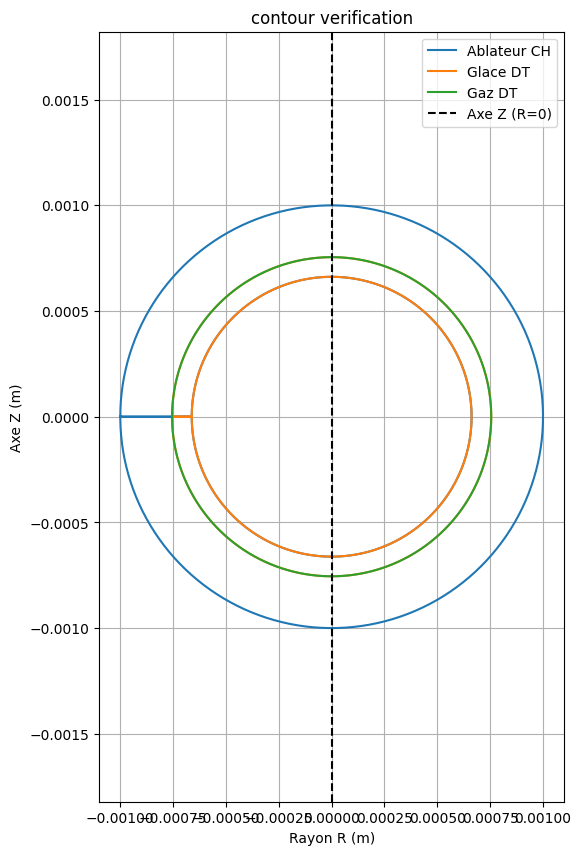

In [30]:
import matplotlib.pyplot as plt


N_points = 500

# Génération des contours avec tes nouvelles fonctions
shell = targetcontour.generate_shell(0.001, 0.000662, N_points)
ice = targetcontour.generate_shell(0.000662, 0.000755, N_points)
gas = targetcontour.generate_sphere(0.000755, N_points)

# Tracé du graphique
plt.figure(figsize=(6, 10))
plt.plot(shell['R'], shell['Z'], label="Ablateur CH")
plt.plot(ice['R'], ice['Z'], label="Glace DT")
plt.plot(gas['R'], gas['Z'], label="Gaz DT")

plt.axvline(x=0, color='black', linestyle='--', label='Axe Z (R=0)')
plt.xlabel('Rayon R (m)')
plt.ylabel('Axe Z (m)')
plt.title('contour verification')
plt.legend()
plt.axis('equal') # Indispensable pour conserver les proportions physiques 
plt.grid(True)
plt.show()

In [31]:
param = {
    "max_step": 50000,          # Maximum number of iterations
    "stop_time": 2e-8,        # Final simulation time 
    "target_radius": 0.001,     # Rt = 1 mm (Ablator outer radius)
    "ray_file_path": "rays_init_mathod_A.txt", # The generated 4-column file

    # --- DATA EXTRACTED FROM THE OMEGA 60 PAPER ---
    "laser_wavelength": 3.51e-07,     # 351 nm (UV)
    "laser_energy": 30000.0,          # 30 kJ (Total energy)
    

    # Shaped cryogenic time profile extracted cleanly from Figure 5
    "laser_profile_t": [
    0.0000000e+00, 3.7988331e-11, 6.5683171e-11, 8.9976560e-11, 9.3556293e-11,
    1.0750458e-10, 1.1453737e-10, 1.1814526e-10, 1.3212170e-10, 1.3579057e-10,
    1.4976701e-10, 1.4989838e-10, 1.5348280e-10, 1.7427153e-10, 2.0177401e-10,
    2.0510508e-10, 2.1185638e-10, 2.2198566e-10, 2.2209826e-10, 2.3565714e-10,
    2.4239436e-10, 2.4564098e-10, 2.5932185e-10, 2.6955435e-10, 2.8673050e-10,
    2.9358031e-10, 3.1082215e-10, 3.2117194e-10, 3.4537149e-10, 3.7306633e-10,
    3.9041607e-10, 4.2515778e-10, 4.4602626e-10, 4.7723984e-10, 4.9457082e-10,
    5.1186426e-10, 5.2223751e-10, 5.3258730e-10, 5.6020238e-10, 5.8092542e-10,
    6.0168130e-10, 6.2598877e-10, 6.5733371e-10, 6.9222555e-10, 7.1318787e-10,
    7.3410796e-10, 7.5847172e-10, 7.7945280e-10, 8.2459122e-10, 8.4547846e-10,
    8.5938453e-10, 8.7322960e-10, 8.9397610e-10, 9.3194567e-10, 9.8022280e-10,
    1.0215281e-09, 1.0524555e-09, 1.0730378e-09, 1.1177634e-09, 1.1555875e-09,
    1.1796557e-09, 1.2106441e-09, 1.2278859e-09, 1.2485948e-09, 1.2693226e-09,
    1.2970174e-09, 1.3178390e-09, 1.3490854e-09, 1.3837849e-09, 1.4219327e-09,
    1.4635055e-09, 1.4911816e-09, 1.5050032e-09, 1.5326230e-09, 1.5567287e-09,
    1.5911326e-09, 1.6289426e-09, 1.6495437e-09, 1.7078140e-09, 1.7283353e-09,
    1.7625422e-09, 1.7898523e-09, 1.8000145e-09, 1.8273246e-09, 1.8683343e-09,
    1.8855058e-09, 1.9061444e-09, 1.9268205e-09, 1.9578886e-09
],
"laser_profile_f": [
    1.8157704e-03, 3.3993398e-03, 2.6167595e-02, 6.5589477e-02, 1.0648824e-01,
    1.5043491e-01, 1.9133995e-01, 2.4132593e-01, 2.9435982e-01, 3.6403478e-01,
    4.1706866e-01, 4.5947569e-01, 5.0188899e-01, 5.2464469e-01, 4.8531694e-01,
    4.4594527e-01, 3.9597811e-01, 3.2178464e-01, 3.5813352e-01, 2.7637365e-01,
    2.2186288e-01, 1.5522954e-01, 1.1284762e-01, 7.1973960e-02, 4.3229143e-02,
    2.5067255e-02, 1.7525950e-02, 1.4515704e-02, 2.3646854e-02, 4.6415109e-02,
    7.3708146e-02, 1.4192505e-01, 1.9042788e-01, 2.3440592e-01, 2.5564081e-01,
    2.6475941e-01, 2.6932185e-01, 2.6631160e-01, 2.6333273e-01, 2.6488492e-01,
    2.7703887e-01, 3.2100436e-01, 4.0738943e-01, 5.2407151e-01, 6.0286507e-01,
    6.6802780e-01, 7.3016773e-01, 8.1501943e-01, 8.9537146e-01, 9.4993243e-01,
    9.8024827e-01, 9.9087513e-01, 1.0000000e+00, 9.9552542e-01, 9.7440977e-01,
    9.3207805e-01, 8.8366936e-01, 8.3978545e-01, 7.8685826e-01, 7.3543304e-01,
    7.0215717e-01, 6.7343745e-01, 6.6589615e-01, 6.6290473e-01, 6.6597146e-01,
    6.8873971e-01, 7.2209717e-01, 7.7667697e-01, 8.3126305e-01, 8.8434086e-01,
    9.2833773e-01, 9.4504784e-01, 9.4810202e-01, 9.4663769e-01, 9.2547810e-01,
    8.8464837e-01, 8.2867955e-01, 7.9085379e-01, 6.5162311e-01, 5.8805022e-01,
    4.8360995e-01, 3.8218620e-01, 3.1859449e-01, 2.1717075e-01, 7.9423221e-02,
    4.9163867e-02, 2.3454399e-02, 9.8612233e-03, 6.8886314e-03
],
    
    'regions': [ reg_shell, reg_dt_ice, reg_dt_gas, ],
    'ambient': ambient,
}



In [32]:
inp = create_input(param)

In [33]:
print(inp)


#
# general parameters
# 
max_step  =  50000    # maximum timestep
stop_time =  2e-08 # maximum problem time


# 
# geometry description
# 
# Coordinate system: XY -> 0, RZ -> 1 
geometry.coord_sys = 1
# Simulation window, limit the real domain of simulation
geometry.prob_lo =   0.0000000e+00   0.0000000e+00 # lower corner  ##falta
geometry.prob_hi =   3.0000000e-03   3.0000000e-03 # upper corner  ##falta
# Periodicity of the domain: no PBC -> 0, PBC -> 1 (must specify the value for both dimensions)
geometry.is_periodic =  0 0

#
# adaptive mesh refinement parameters	##esto hay que cambiarlo?
#
amr.v               = 1               # Verbose output
amr.n_cell          = 256 256          # number of cells for base level
amr.max_level       = 3              # maximum level number allowed
amr.ref_ratio       = 2 2 2 2 2 2 2 2 # refinement ratio 
amr.regrid_int      = 2               # how often to regrid
amr.n_error_buf     = 2 2 2 2 2 2 2 2 # number of buffer cells in error est
amr.grid

In [34]:
file_name = 'input_file_method_A.txt'

with open(file_name, 'w') as f:
    print(inp, file=f)